# 1. Импорты

In [1]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='Set2')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip


# 2. Загрузка датасетов

In [2]:
train = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip')
test = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip')

print('Обучающая выборка:', train.shape)
print('Тестовая выборка:', test.shape)

Обучающая выборка: (100000, 9)
Тестовая выборка: (100000, 8)


# 3. ETL

In [3]:
def transform(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ['Month', 'DayofMonth', 'DayOfWeek']:
        df[col] = df[col].str.replace('c-', '', regex=False).astype(int)

    df['DepHour'] = (df['DepTime'] // 100).clip(0, 23).astype(int)
    df['DepMinute'] = (df['DepTime'] % 100).clip(0, 59).astype(int)
    df['DepTimeMinutes'] = df['DepHour'] * 60 + df['DepMinute']
    df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
    return df


train_df = transform(train)
test_df = transform(test)
train_df['target'] = (train_df['dep_delayed_15min'] == 'Y').astype(int)

train_df.head()

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min,DepHour,DepMinute,DepTimeMinutes,IsWeekend,target
0,8,21,7,1934,AA,ATL,DFW,732,N,19,34,1174,1,0
1,4,20,3,1548,US,PIT,MCO,834,N,15,48,948,0,0
2,9,2,5,1422,XE,RDU,CLE,416,N,14,22,862,0,0
3,11,25,6,1015,OO,DEN,MEM,872,N,10,15,615,1,0
4,10,7,6,1828,WN,MDW,OMA,423,Y,18,28,1108,1,1


# 4. EDA

Доля задержанных рейсов: 0.1904


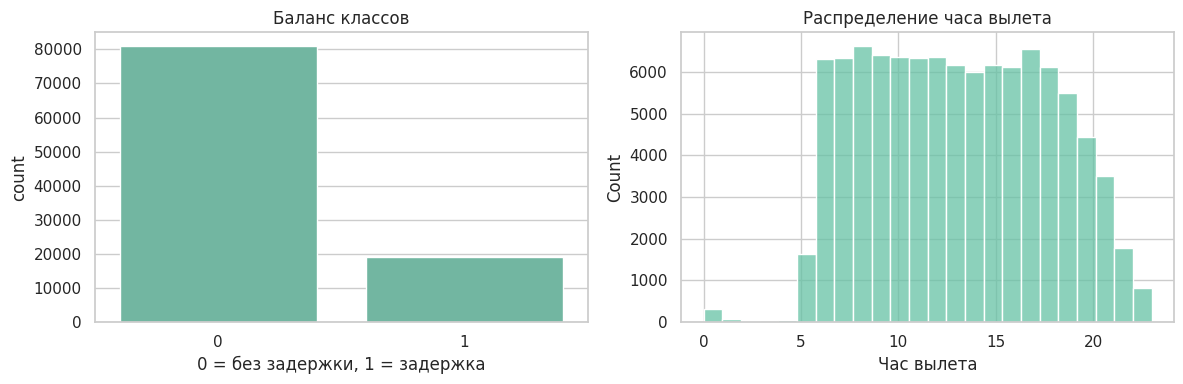

In [4]:
print('Доля задержанных рейсов:', round(train_df['target'].mean(), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_df, x='target', ax=axes[0])
axes[0].set_title('Баланс классов')
axes[0].set_xlabel('0 = без задержки, 1 = задержка')

sns.histplot(data=train_df, x='DepHour', bins=24, ax=axes[1])
axes[1].set_title('Распределение часа вылета')
axes[1].set_xlabel('Час вылета')

plt.tight_layout()
plt.show()

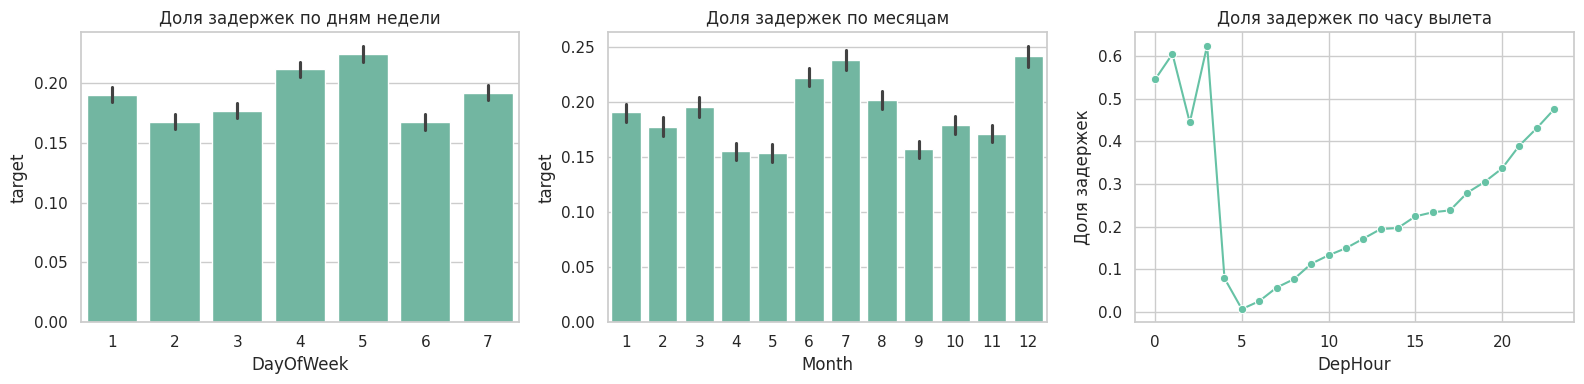

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=train_df, x='DayOfWeek', y='target', estimator=np.mean, ax=axes[0])
axes[0].set_title('Доля задержек по дням недели')

sns.barplot(data=train_df, x='Month', y='target', estimator=np.mean, ax=axes[1])
axes[1].set_title('Доля задержек по месяцам')

sns.lineplot(data=train_df.groupby('DepHour')['target'].mean().reset_index(), x='DepHour', y='target', marker='o', ax=axes[2])
axes[2].set_title('Доля задержек по часу вылета')
axes[2].set_ylabel('Доля задержек')

plt.tight_layout()
plt.show()
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)


def build_features(train_df, test_df, num_features, cat_features):
    ohe = make_ohe()
    ohe.fit(pd.concat([train_df[cat_features], test_df[cat_features]], axis=0))

    X = hstack([
        train_df[num_features].astype(float).values,
        ohe.transform(train_df[cat_features]),
    ]).tocsr()

    X_test = hstack([
        test_df[num_features].astype(float).values,
        ohe.transform(test_df[cat_features]),
    ]).tocsr()

    return X, X_test, ohe


y = train_df['target'].values

# 5. Подготовка матрицы признаков

Почему one-hot: логистическая регрессия не умеет напрямую работать со строковыми категориями. One-hot превращает авиакомпании и аэропорты в числовые бинарные признаки, а разреженная матрица экономит память.

In [6]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)


def build_features(train_df, test_df, num_features, cat_features):
    ohe = make_ohe()
    ohe.fit(pd.concat([train_df[cat_features], test_df[cat_features]], axis=0))

    X = hstack([
        train_df[num_features].astype(float).values,
        ohe.transform(train_df[cat_features]),
    ]).tocsr()

    X_test = hstack([
        test_df[num_features].astype(float).values,
        ohe.transform(test_df[cat_features]),
    ]).tocsr()

    return X, X_test, ohe


y = train_df['target'].values

# 6. Модель логистической регрессии

In [7]:
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest']

X_base, X_test_base, ohe_base = build_features(train_df, test_df, NUM_FEATURES, CAT_FEATURES)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

baseline_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
baseline_model.fit(X_tr, y_tr)

baseline_val_pred = baseline_model.predict_proba(X_val)[:, 1]
baseline_auc = roc_auc_score(y_val, baseline_val_pred)
print('ROC AUC логистической регрессии:', round(baseline_auc, 5))

ROC AUC логистической регрессии: 0.70138
